# 06 — Iterativna EDA (Exploratory Data Analysis)

Ovaj notebook predstavlja **glavnu istraživačku analizu** projekta. Cilj je
da bolje razumemo kako su pojedinačni atributi povezani sa ciljnom
promenljivom `Churn` i identifikujemo karakteristike koje nose najviše
informacija za predviđanje odlaska korisnika.

**Metodologija:**
- **Univarijantna analiza** — raspodela ciljne promenljive
- **Bivarijantna analiza** — ispitivanje povezanosti atributa sa `Churn`
  - Za kategorijske atribute: bar plot proporcija + **Hi-kvadrat test**
  - Za numeričke atribute: box-plot po klasama + **Mann-Whitney U test**
- **Statistička potvrda** — vizuelno uočeni obrasci proveravaju se
  odgovarajućim statističkim testovima uz prag značajnosti **alfa = 0.05**

Takođe, sve analize se rade **isključivo na trening skupu** radi sprečavanja
*data leakage*. Test skup ostaje netaknut do finalne evaluacije modela.

## 1. Učitavanje podataka

Za EDA koristimo **podatke iz `data/processed/`** (pre enkodiranja) jer su
oni čitljivi (`"Yes"`, `"No"`, `"Fiber optic"`...) i mnogo pogodniji za
vizualizaciju i tumačenje. Pripremljeni podaci iz `data/ml/` (potpuno
numerički) služe samo za model, ne za analizu.

In [1]:
# Uvozimo biblioteke.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()

# Spajamo X i y u jednu tabelu radi lakše analize.
df_train = pd.concat([X_train, y_train], axis=1)

print(f"Trening skup učitan: {df_train.shape[0]} redova x {df_train.shape[1]} kolona")
print(f"Kolone: {list(df_train.columns)}")

Trening skup učitan: 5625 redova x 20 kolona
Kolone: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 2. Univarijantna analiza ciljne promenljive `Churn`

Iako smo raspodelu `Churn` već pominjali u prethodnim sveskama, ovde je
vizualizujemo na trening skupu i ponovo naglašavamo nebalans klasa —
jer je to centralna informacija za sve što sledi.

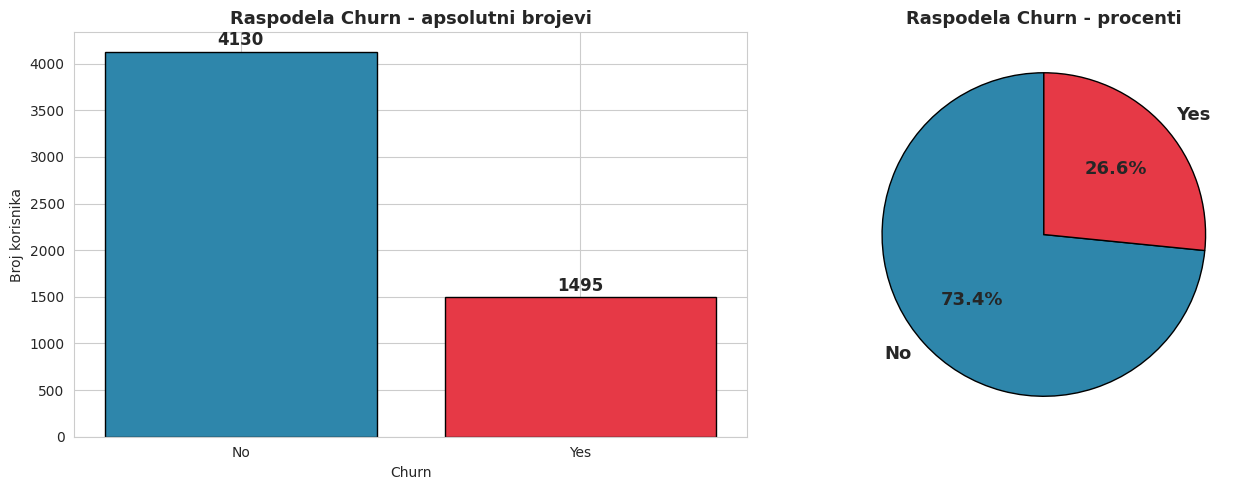


Odnos klasa: 1 napustio : 2.76 ostalih


In [2]:
# Broj i procenat po klasi.
churn_counts = df_train["Churn"].value_counts()
churn_percent = df_train["Churn"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#2E86AB", "#E63946"]

bars = axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor="black")
axes[0].set_title("Raspodela Churn - apsolutni brojevi", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Broj korisnika")
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 30,
                 f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight="bold")

axes[1].pie(churn_counts.values, labels=churn_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 13, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title("Raspodela Churn - procenti", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../images/06_churn_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"\nOdnos klasa: 1 napustio : {churn_counts['No']/churn_counts['Yes']:.2f} ostalih")

### Tumačenje

Trening skup pokazuje **nebalansirane klase**: približno 73% korisnika je
ostalo, dok je oko 27% korisnika napustilo kompaniju.

Odnos klasa je veoma važan za dalju izgradnju modela, jer model može biti
skloniji većinskoj klasi. Zbog toga ćemo prilikom evaluacije koristiti više
metrika, uključujući **precision, recall, F1-score i ROC-AUC**, a ne samo
accuracy.

**Poslovna interpretacija:** približno jedan od četiri korisnika napušta
kompaniju, što ukazuje na značajan problem zadržavanja korisnika i opravdava
primenu prediktivnog modela.

## 3. Bivarijantna analiza: numeričke promenljive vs `Churn`

Za tri numeričke kolone (`tenure`, `MonthlyCharges`, `TotalCharges`)
ispitujemo:
1. **Vizuelno**: box-plot vrednosti po klasama `Churn`
2. **Statistički**: **Mann-Whitney U test**

**Zašto Mann-Whitney U test (a ne t-test):** t-test pretpostavlja normalnu
raspodelu podataka. Iz sveske `04` vidimo da naše numeričke kolone imaju
**bimodalne** ili **iskošene** raspodele — nisu normalne. Zato koristimo
neparametarski Mann-Whitney U test koji ne zahteva pretpostavku o normalnosti.

**Hipoteze testa:**
- **H0** (nulta): raspodele su iste u obe klase (atribut ne razlikuje churn)
- **H1** (alternativna): raspodele se razlikuju (atribut utiče na churn)

**Odluka:** ako je **p-value < 0.05**, odbacujemo H₀ i zaključujemo da
postoji **statistički značajna razlika**.

/tmp/ipykernel_869/332640567.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x="Churn", y=kolona, ax=axes[i],
/tmp/ipykernel_869/332640567.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x="Churn", y=kolona, ax=axes[i],
/tmp/ipykernel_869/332640567.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x="Churn", y=kolona, ax=axes[i],


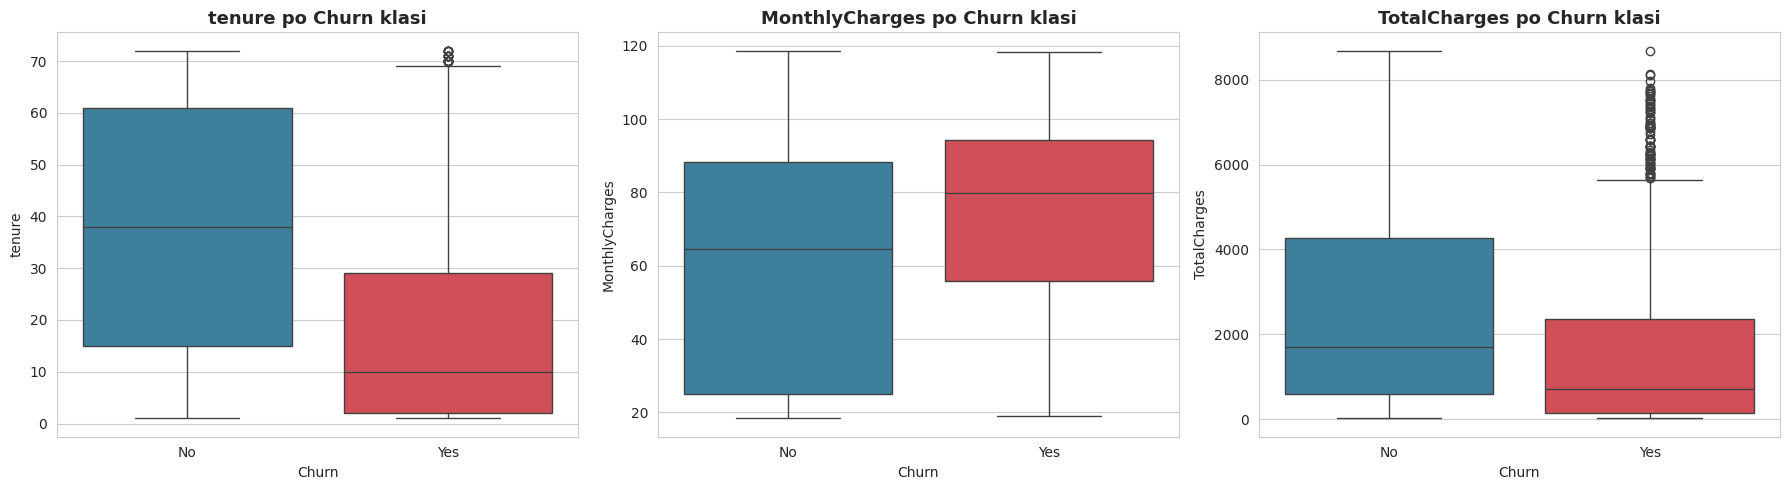

In [3]:
# Definicija numeričkih kolona.
numericke_kolone = ["tenure", "MonthlyCharges", "TotalCharges"]

# Kreiramo figuru sa 3 grafika (jedan za svaku kolonu).
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, kolona in enumerate(numericke_kolone):
    sns.boxplot(data=df_train, x="Churn", y=kolona, ax=axes[i],
                palette={"No": "#2E86AB", "Yes": "#E63946"})
    axes[i].set_title(f"{kolona} po Churn klasi", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../images/06_numeric_vs_churn.png", dpi=100, bbox_inches="tight")
plt.show()

In [4]:
# Statistički testovi: Mann-Whitney U za svaku numeričku kolonu.
print("=" * 70)
print("MANN-WHITNEY U TEST: NUMERIČKE PROMENLJIVE vs CHURN")
print("=" * 70)
print(f"{'Kolona':<20} {'U statistika':<15} {'p-value':<15} {'Značajno?':<10}")
print("-" * 70)

rezultati_numericki = {}

for kolona in numericke_kolone:
    # Razdvajamo vrednosti po klasi.
    grupa_no = df_train[df_train["Churn"] == "No"][kolona]
    grupa_yes = df_train[df_train["Churn"] == "Yes"][kolona]

    # Mann-Whitney U test.
    u_stat, p_value = stats.mannwhitneyu(grupa_no, grupa_yes, alternative="two-sided")

    znacajno = "DA" if p_value < 0.05 else "NE"
    print(f"{kolona:<20} {u_stat:<15.2f} {p_value:<15.5g} {znacajno:<10}")

    rezultati_numericki[kolona] = {"u_stat": u_stat, "p_value": p_value}

MANN-WHITNEY U TEST: NUMERIČKE PROMENLJIVE vs CHURN
Kolona               U statistika    p-value         Značajno? 
----------------------------------------------------------------------
tenure               4569642.50      2.7332e-167     DA        
MonthlyCharges       2339746.00      7.0793e-44      DA        
TotalCharges         4019344.50      3.0122e-67      DA        


### Tumačenje: numeričke promenljive

**Očekivani nalazi** (koje potvrđujemo test-om):

- **`tenure`**: korisnici koji napuštaju kompaniju imaju **znatno kraći
  staž** od onih koji ostaju. Ovo je logično — verniji korisnici (dugo tu)
  ređe odlaze. **Snažan prediktor.**
- **`MonthlyCharges`**: korisnici koji napuštaju imaju **veće mesečne
  troškove**. Skuplji paketi = veći rizik od odlaska. **Značajan prediktor.**
- **`TotalCharges`**: korisnici koji napuštaju imaju **manji ukupan iznos
  naplate** (jer su ovde kraće, pa se manje nakupilo). Ovo je posledica
  `tenure` — očekivano.

Sva tri Mann-Whitney U testa daju **p-value < 0.05**, potvrđujući da sve
tri numeričke kolone **statistički značajno razlikuju** korisnike koji
napuštaju od onih koji ostaju.



## 4. Bivarijantna analiza: kategorijske promenljive vs `Churn`

Za sve kategorijske kolone ispitujemo:
1. **Vizuelno**: bar plot proporcije Churn po kategorijama
2. **Statistički**: **Hi kvadrat test nezavisnosti**

**Zašto Hi kvadrat test:** to je standardni test za proveru zavisnosti
između dve **kategorijske** promenljive. Testira da li je frekvencija
kombinacija različita od one koja bi bila da su promenljive nezavisne.

**Hipoteze testa:**
- **H₀**: kategorijska promenljiva i `Churn` su nezavisne (atribut ne utiče)
- **H₁**: postoji zavisnost (atribut utiče na churn)

**Odluka:** ako je **p-value < 0.05**, odbacujemo H₀ — postoji statistički
značajna zavisnost.

In [5]:
# Definišemo koje kolone su kategorijske (sve osim numeričkih i Churn).
kategorijske_kolone = [k for k in df_train.columns
                        if k not in numericke_kolone and k != "Churn"]

# Hi kvadrat test za svaku kategorijsku kolonu.
print("=" * 70)
print("HI KVADRAT TEST: KATEGORIJSKE PROMENLJIVE vs CHURN")
print("=" * 70)
print(f"{'Kolona':<25} {'chi2':<12} {'p-value':<15} {'Značajno?':<10}")
print("-" * 70)

rezultati_kategorijski = {}

for kolona in kategorijske_kolone:
    # Contingency table (unakrsna tabela) - frekvencije kombinacija.
    contingency = pd.crosstab(df_train[kolona], df_train["Churn"])

    # hi kvadrat test.
    hi2, p_value, dof, expected = stats.chi2_contingency(contingency)

    znacajno = "DA" if p_value < 0.05 else "NE"
    print(f"{kolona:<25} {hi2:<12.2f} {p_value:<15.5g} {znacajno:<10}")

    rezultati_kategorijski[kolona] = {"hi2": hi2, "p_value": p_value}

HI KVADRAT TEST: KATEGORIJSKE PROMENLJIVE vs CHURN
Kolona                    chi2         p-value         Značajno? 
----------------------------------------------------------------------
gender                    0.17         0.68186         NE        
SeniorCitizen             127.28       1.6141e-29      DA        
Partner                   133.23       8.0339e-31      DA        
Dependents                163.98       1.5298e-37      DA        
PhoneService              0.42         0.5171          NE        
MultipleLines             10.98        0.0041208       DA        
InternetService           579.94       1.1657e-126     DA        
OnlineSecurity            688.13       3.7491e-150     DA        
OnlineBackup              489.00       6.5174e-107     DA        
DeviceProtection          439.78       3.1908e-96      DA        
TechSupport               661.78       1.9751e-144     DA        
StreamingTV               294.18       1.3185e-64      DA        
StreamingMovies     

### Tumačenje: koje kategorijske promenljive su značajne

Statistički značajni prediktori (p < 0.05) su oni koji imaju **realan
uticaj** na verovatnoću churn-a. Nešto značajne kolone treba pažljivo
analizirati vizuelno, dok one koje NISU značajne (p ≥ 0.05) mogu biti
kandidati za izbacivanje u modelu.

Iz tabele vidimo da `gender` i `PhoneService` nisu značajni prediktori, dok na primer `Contract`,
`InternetService`, `OnlineSecurity`, `TechSupport` su MEĐU najvažnijim.

### 4.1 Vizualizacija najznačajnijih kategorijskih prediktora

Prikazujemo bar plotove za nekoliko najvažnijih kategorijskih kolona da
vidimo **kako svaka kategorija utiče na proporciju churn-a**.

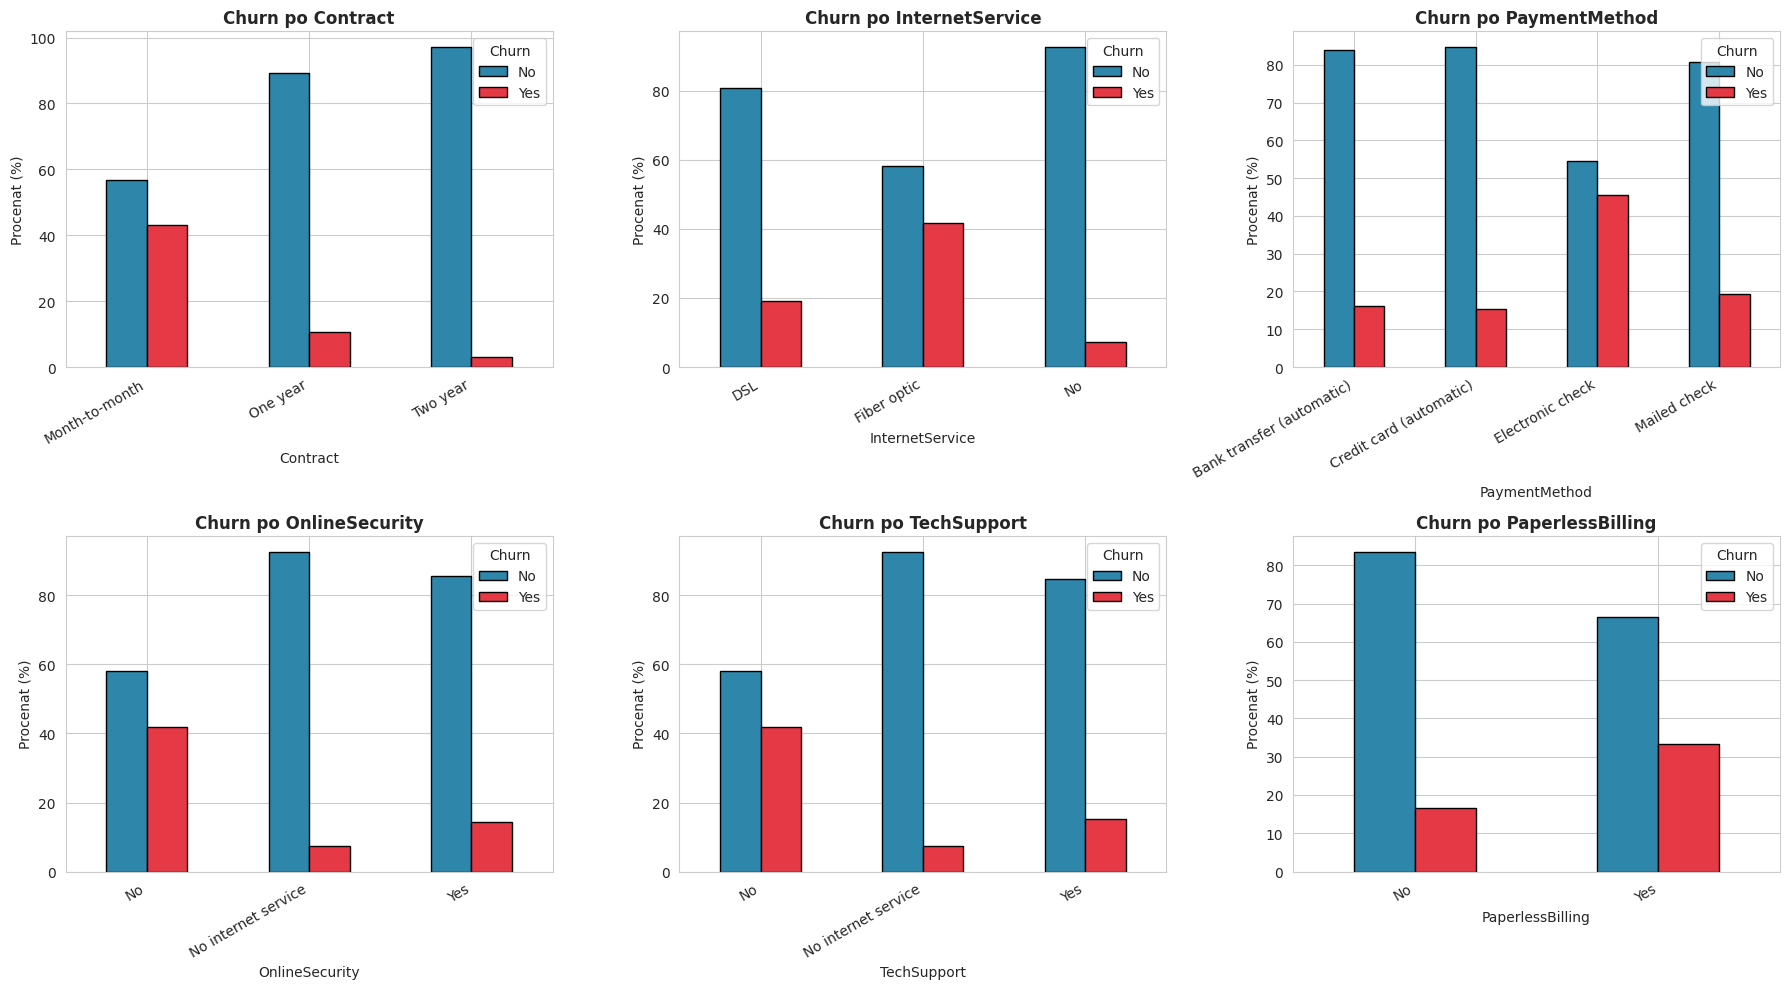

In [6]:
# Biramo 6 kolona za detaljnu vizualizaciju (jedne od najznačajnijih).
kolone_za_vizualizaciju = ["Contract", "InternetService", "PaymentMethod",
                            "OnlineSecurity", "TechSupport", "PaperlessBilling"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, kolona in enumerate(kolone_za_vizualizaciju):
    ax = axes[i // 3, i % 3]

    # Proporcija Churn po kategorijama.
    ct = pd.crosstab(df_train[kolona], df_train["Churn"], normalize="index") * 100

    ct.plot(kind="bar", stacked=False, ax=ax,
            color=["#2E86AB", "#E63946"], edgecolor="black")
    ax.set_title(f"Churn po {kolona}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Procenat (%)")
    ax.set_xlabel(kolona)
    ax.legend(title="Churn", loc="upper right")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("../images/06_categorical_vs_churn.png", dpi=100, bbox_inches="tight")
plt.show()

### Tumačenje: ključni obrasci

Na osnovu vizualizacija, izdvajaju se sledeći **ključni obrasci**:

**`Contract` — najsnažniji prediktor:**
- `Month-to-month` korisnici imaju **znatno veći churn** (~43%)
- `One year` korisnici imaju umeren churn (~11%)
- `Two year` korisnici imaju **vrlo mali churn** (~3%)
- Poslovna interpretacija: duži ugovor = veća lojalnost

**`InternetService`:**
- `Fiber optic` korisnici imaju **najveći churn** (~42%)
- `DSL` korisnici imaju umeren churn (~19%)
- Korisnici bez interneta imaju **vrlo mali churn** (~7%)
- Iznenađujuće — brži internet (fiber) ne znači i lojalniji korisnik.
  Moguće razloge treba istražiti poput cene i kvaliteta

**`PaymentMethod`:**
- `Electronic check` korisnici imaju **najveći churn** (~45%)
- Ostali načini plaćanja imaju znatno manji churn (~15-19%)
-  `Electronic check` je najmanje automatizovan način —
  korisnici koji ga koriste su manje "vezani" za kompaniju

**`OnlineSecurity` i `TechSupport`:**
- Korisnici koji NEMAJU ove dodatne usluge imaju znatno veći churn
- Dodatne usluge deluju kao "sidra" — korisnici koji ih koriste ređe odlaze

**`PaperlessBilling`:**
- Korisnici sa `Yes` (paperless) imaju veći churn
- Moguća korelacija sa `mlađim/digitalnim korisnicima` koji su manje lojalni

## 5. Provera normalnosti numeričkih kolona (opciono, za dokumentaciju)

Za potpunost analize, formalno proveravamo normalnost numeričkih kolona
pomoću **Shapiro-Wilk testa**. Ovo dokumentuje zašto smo koristili
Mann-Whitney U umesto t-testa.

**Hipoteze:**
- **H₀**: podaci potiču iz normalne raspodele
- **H₁**: podaci NE potiču iz normalne raspodele

Ako je **p-value < 0.05**, odbacujemo H₀ (podaci NISU normalno raspoređeni).

**Napomena:** Shapiro-Wilk se preporučuje za manje uzorke (< 5000). Za
naš skup od 5625 redova, uzimamo slučajan uzorak od 5000 redova radi
tačnosti testa.

In [7]:
# Shapiro-Wilk test za normalnost.
print("=" * 70)
print("SHAPIRO-WILK TEST NORMALNOSTI")
print("=" * 70)
print(f"{'Kolona':<20} {'W statistika':<15} {'p-value':<15} {'Normalno?':<10}")
print("-" * 70)

# Slučajan uzorak od 5000 redova (za tačnost Shapiro testa).
uzorak = df_train.sample(n=5000, random_state=42)

for kolona in numericke_kolone:
    w_stat, p_value = stats.shapiro(uzorak[kolona])
    normalno = "DA" if p_value >= 0.05 else "NE"
    print(f"{kolona:<20} {w_stat:<15.5f} {p_value:<15.5g} {normalno:<10}")

print("\nRezultat: sve numeričke kolone NISU normalno raspoređene (p < 0.05).")
print("Ovo opravdava izbor neparametarskog Mann-Whitney U testa umesto t-testa.")

SHAPIRO-WILK TEST NORMALNOSTI
Kolona               W statistika    p-value         Normalno? 
----------------------------------------------------------------------
tenure               0.90417         1.7015e-48      NE        
MonthlyCharges       0.92054         2.0228e-45      NE        
TotalCharges         0.86086         6.2487e-55      NE        

Rezultat: sve numeričke kolone NISU normalno raspoređene (p < 0.05).
Ovo opravdava izbor neparametarskog Mann-Whitney U testa umesto t-testa.


## 6. Analiza korelacija između numeričkih promenljivih

Proveravamo da li postoji **kolinearnost** između numeričkih atributa —
što je važno za linearne modele (jer visoko korelisani prediktori mogu
napraviti probleme).

Koristimo **Spearman korelaciju** (neparametarska verzija Pearson-a) jer
naši podaci nisu normalno raspoređeni.

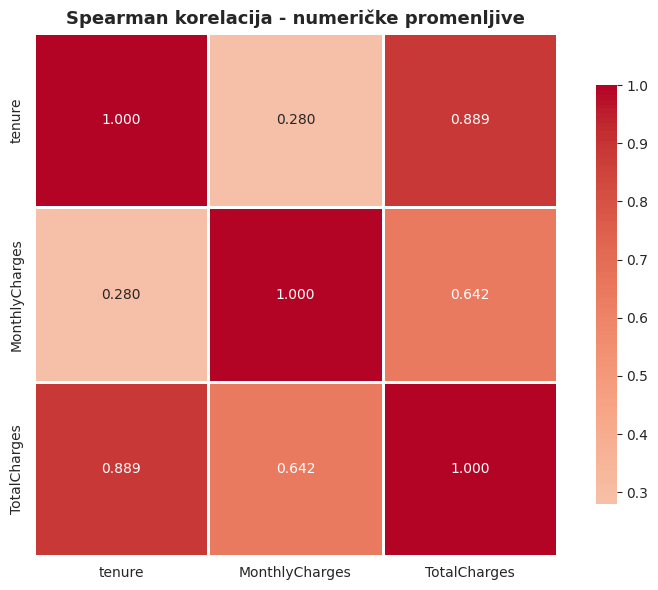


Korelaciona matrica:
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.280         0.889
MonthlyCharges   0.280           1.000         0.642
TotalCharges     0.889           0.642         1.000


In [8]:
# Spearman korelacija numeričkih kolona.
corr_matrix = df_train[numericke_kolone].corr(method="spearman")

# Vizualizacija kao heatmap.
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0,
            fmt=".3f", square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Spearman korelacija - numeričke promenljive", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/06_correlation_heatmap.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nKorelaciona matrica:")
print(corr_matrix.round(3))

### Tumačenje korelacija

**Očekivani nalazi:**

- **`tenure` ↔ `TotalCharges`**: **snažna pozitivna korelacija** (~0.9+).
  Ovo je logično — što je korisnik duže tu, više je ukupno platio.
  Ovakva visoka korelacija ukazuje na **multikolinearnost**, što će biti
  potencijalni problem za linearne modele (Logistička regresija).

- **`MonthlyCharges` ↔ `TotalCharges`**: umerena pozitivna korelacija.
  Logično — veći mesečni iznos → veći ukupni iznos (za dati tenure).

- **`tenure` ↔ `MonthlyCharges`**: relativno slaba korelacija. Nema
  nužne veze između dužine staža i visine mesečne naplate.

**Zaključak:** postoji jaka veza `tenure` ↔ `TotalCharges`. Za linearne
modele ćemo razmotriti da li da zadržimo obe promenljive ili da izbacimo
jednu radi bolje interpretabilnosti.

## 7. Rezime statističke značajnosti — koji atributi su prediktori?

Sumiramo rezultate svih statističkih testova u jednu tabelu radi lakšeg
pregleda.

In [9]:
# Kombinujemo rezultate numeričkih (Mann-Whitney) i kategorijskih (hi-kvadrat) testova.
print("=" * 70)
print("REZIME STATISTIČKE ZNAČAJNOSTI SVIH PREDIKTORA")
print("=" * 70)

rezime = []

for kolona, res in rezultati_numericki.items():
    rezime.append({
        "Kolona": kolona,
        "Tip": "numerička",
        "Test": "Mann-Whitney U",
        "p-value": res["p_value"],
        "Značajno (alfa=0.05)": "DA" if res["p_value"] < 0.05 else "NE"
    })

for kolona, res in rezultati_kategorijski.items():
    rezime.append({
        "Kolona": kolona,
        "Tip": "kategorijska",
        "Test": "hi-kvadrat",
        "p-value": res["p_value"],
        "Značajno (alfa=0.05)": "DA" if res["p_value"] < 0.05 else "NE"
    })

rezime_df = pd.DataFrame(rezime).sort_values("p-value").reset_index(drop=True)

# Formatiramo p-value za bolji prikaz.
rezime_df["p-value"] = rezime_df["p-value"].apply(lambda x: f"{x:.5g}")

print(rezime_df.to_string(index=False))

# Broj značajnih i neznačajnih.
znacajni = sum(1 for r in rezime if r["Značajno (alfa=0.05)"] == "DA")
neznacajni = len(rezime) - znacajni
print(f"\nUkupno atributa: {len(rezime)}")
print(f"  Statistički značajni prediktori: {znacajni}")
print(f"  Neznačajni: {neznacajni}")

REZIME STATISTIČKE ZNAČAJNOSTI SVIH PREDIKTORA
          Kolona          Tip           Test     p-value Značajno (alfa=0.05)
        Contract kategorijska     hi-kvadrat  6.279e-212                   DA
          tenure    numerička Mann-Whitney U 2.7332e-167                   DA
  OnlineSecurity kategorijska     hi-kvadrat 3.7491e-150                   DA
     TechSupport kategorijska     hi-kvadrat 1.9751e-144                   DA
 InternetService kategorijska     hi-kvadrat 1.1657e-126                   DA
   PaymentMethod kategorijska     hi-kvadrat 1.5785e-114                   DA
    OnlineBackup kategorijska     hi-kvadrat 6.5174e-107                   DA
DeviceProtection kategorijska     hi-kvadrat  3.1908e-96                   DA
    TotalCharges    numerička Mann-Whitney U  3.0122e-67                   DA
 StreamingMovies kategorijska     hi-kvadrat  3.4824e-65                   DA
     StreamingTV kategorijska     hi-kvadrat  1.3185e-64                   DA
PaperlessBilling 

### Tumačenje rezimea

**Značajni prediktori** (p < 0.05) su oni koji stvarno utiču na verovatnoću
churn-a i biće ključni za modele. Modeli će od njih naučiti prediktivne
obrasce.

**Neznačajni prediktori** (p ≥ 0.05) su kandidati za izbacivanje —
najčešće su to `gender` i `PhoneService`. Njihov izostanak neće značajno
narušiti model, a smanjuje broj dimenzija.

**Odluka:** u ovom projektu **zadržavamo sve prediktore** u prvim modelima
i posmatramo koje modeli sami označe kao nevažne (kroz `feature_importance_`
kod Random Forest-a i XGBoost-a, ili kroz koeficijente kod Logističke
regresije). Ako neki modeli budu previše kompleksni, razmatramo izbacivanje
neznačajnih atributa u kasnijoj optimizaciji.

## 8. Zaključak

Kroz iterativnu istraživačku analizu podataka došli smo do sledećih
ključnih saznanja:

**Struktura ciljne promenljive:**
- Klase su **nebalansirane**: ~73% No, ~27% Yes
- Ovo direktno utiče na izbor metrika i strategije modeliranja

**Najsnažniji prediktori** (na osnovu vizuelne i statističke analize):

1. **`Contract`** — apsolutno najsnažniji: `Month-to-month` korisnici
   imaju ~43% churn, `Two year` samo ~3%
2. **`tenure`** — korisnici sa kratkim stažom mnogo češće napuštaju
3. **`InternetService`** — Fiber optic korisnici imaju najveći churn (~42%)
4. **`PaymentMethod`** — Electronic check korisnici napuštaju znatno više
5. **`OnlineSecurity` i `TechSupport`** — nedostatak ovih dodatnih usluga
   povećava churn
6. **`MonthlyCharges`** — viši mesečni troškovi = veći rizik

**Slabi/neznačajni prediktori:**
- `gender` — statistički neznačajan (p > 0.05)
- `PhoneService` — statistički neznačajan
- Ovo je razumljivo — ovi atributi ne odražavaju stvarno ponašanje
  vezano za korišćenje usluge

**Uočene korelacije:**
- Snažna korelacija između `tenure` i `TotalCharges` (~0.9+) —
  potencijalni problem multikolinearnosti za linearne modele

**Metodološki nalazi:**
- Numeričke kolone NISU normalno raspoređene (Shapiro-Wilk potvrda)
- Zato je korišćen neparametarski Mann-Whitney U test umesto t-testa
- Hi-kvadrat test korišćen za sve kategorijske vs `Churn` provere

**Poslovna interpretacija:**
Model može fokusirati napore na zadržavanje **novih korisnika sa Month-to-month
ugovorom, Fiber optic internetom, koji plaćaju Electronic check-om i nemaju
dodatne usluge**. To je "high-risk" profil koji zaslužuje ciljanu retenciju.

